# Forest Mask Texture Test

`services/forest_mask/cli.py` の `main` をプロジェクトルートから実行する想定でテストする。

ExG にローカル分散ベースのテクスチャ計算 (`calc_texture`) を適用してから閾値処理する流れを確認する。

- 入力: `data/input/jpg/sample/sample_tree.jpg`
- 出力:
  - `data/intermediate/exg/exg_<timestamp>.jpg`
  - `data/intermediate/exg/texture_<timestamp>.jpg`
  - `data/intermediate/forest_mask/fmask_<timestamp>.jpg`
  - `data/intermediate/forest_mask/fmask_morph_<timestamp>.jpg`
  - `data/intermediate/forest_mask/compo_<timestamp>.jpg`

In [1]:
# プロジェクトルートで実行できるようにカレントを移動
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)

print("cwd:", Path.cwd())

cwd: /home/mqsol/works/forest-analyzer


In [2]:
# モジュールリロードを有効化（実装変更を即反映するため）
%load_ext autoreload
%autoreload 2

In [3]:
from click.testing import CliRunner

from services.forest_mask.cli import main

INPUT_PATH = "data/input/jpg/sample/sample_tree.jpg"
THRESHOLD = 10.0
TEXTURE_KERNEL = 5
CLOSING = 5
OPENING = 3

runner = CliRunner()
result = runner.invoke(
    main,
    [
        INPUT_PATH,
        "--threshold", str(THRESHOLD),
        "--texture-kernel", str(TEXTURE_KERNEL),
        "--closing", str(CLOSING),
        "--opening", str(OPENING),
    ],
    catch_exceptions=False,
)

print(result.output)
assert result.exit_code == 0, f"exit_code={result.exit_code}"

Saved: data/intermediate/exg/exg_20260520173934.jpg
Saved: data/intermediate/exg/texture_20260520173934.jpg
Saved: data/intermediate/forest_mask/fmask_20260520173934.jpg
Saved: data/intermediate/forest_mask/fmask_morph_20260520173934.jpg
Saved: data/intermediate/forest_mask/compo_20260520173934.jpg



latest exg     : data/intermediate/exg/exg_20260520173934.jpg
latest texture : data/intermediate/exg/texture_20260520173934.jpg
latest mask    : data/intermediate/forest_mask/fmask_20260520173934.jpg
latest morph   : data/intermediate/forest_mask/fmask_morph_20260520173934.jpg
latest compo   : data/intermediate/forest_mask/compo_20260520173934.jpg


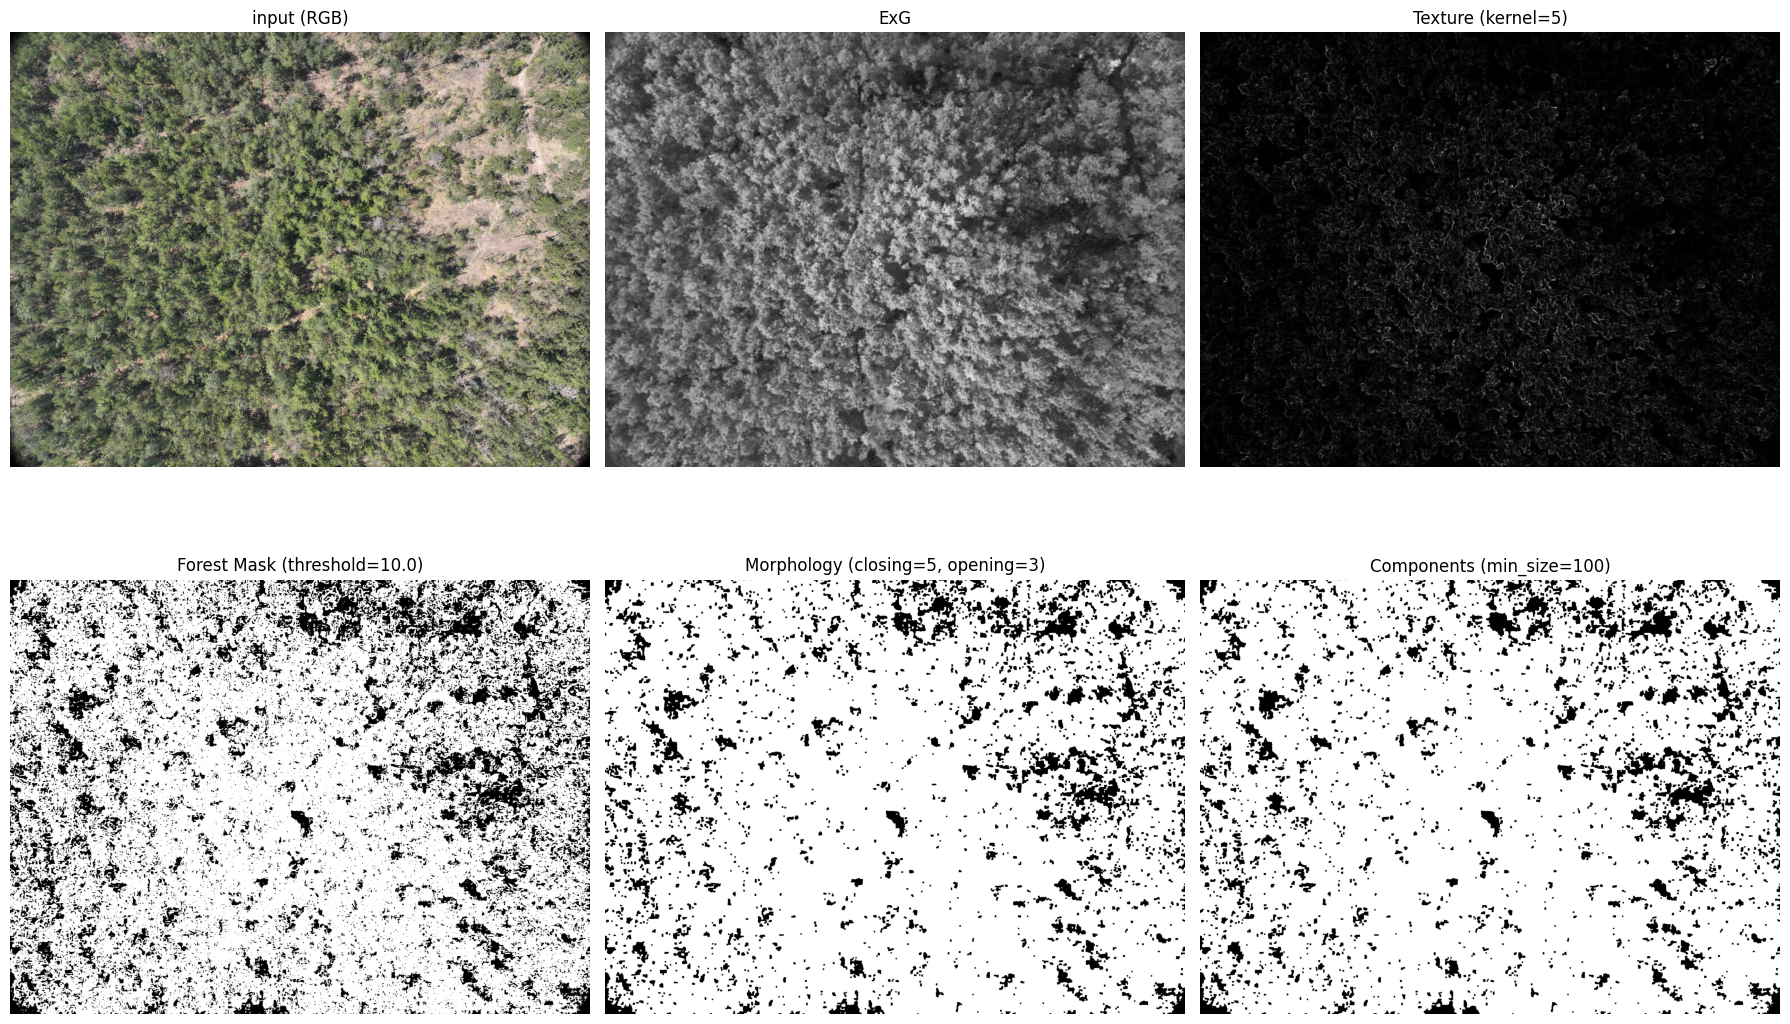

In [4]:
# 出力結果の確認: 入力・ExG・Texture・Forest Mask・Morphology・Components を並べて表示
import cv2
import matplotlib.pyplot as plt

from services.common.image import load_rgb

exg_dir = Path("data/intermediate/exg")
mask_dir = Path("data/intermediate/forest_mask")

latest_exg = max(
    (p for p in exg_dir.glob("exg_*.jpg")),
    key=lambda p: p.stat().st_mtime,
)
latest_texture = max(
    exg_dir.glob("texture_*.jpg"),
    key=lambda p: p.stat().st_mtime,
)
latest_mask = max(
    (p for p in mask_dir.glob("fmask_*.jpg") if not p.name.startswith("fmask_morph_")),
    key=lambda p: p.stat().st_mtime,
)
latest_morph = max(mask_dir.glob("fmask_morph_*.jpg"), key=lambda p: p.stat().st_mtime)
latest_compo = max(mask_dir.glob("compo_*.jpg"), key=lambda p: p.stat().st_mtime)
print("latest exg     :", latest_exg)
print("latest texture :", latest_texture)
print("latest mask    :", latest_mask)
print("latest morph   :", latest_morph)
print("latest compo   :", latest_compo)

rgb = load_rgb(Path(INPUT_PATH))
exg = cv2.imread(str(latest_exg), cv2.IMREAD_GRAYSCALE)
texture = cv2.imread(str(latest_texture), cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(str(latest_mask), cv2.IMREAD_GRAYSCALE)
morph_mask = cv2.imread(str(latest_morph), cv2.IMREAD_GRAYSCALE)
compo_mask = cv2.imread(str(latest_compo), cv2.IMREAD_GRAYSCALE)

panels = [
    ("input (RGB)", rgb, None),
    ("ExG", exg, "gray"),
    (f"Texture (kernel={TEXTURE_KERNEL})", texture, "gray"),
    (f"Forest Mask (threshold={THRESHOLD})", mask, "gray"),
    (f"Morphology (closing={CLOSING}, opening={OPENING})", morph_mask, "gray"),
    ("Components (min_size=100)", compo_mask, "gray"),
]

n_cols = 3
n_rows = (len(panels) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else list(axes)

for ax, (title, img, cmap) in zip(axes, panels):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

for ax in axes[len(panels):]:
    ax.axis("off")

plt.tight_layout()
plt.show()